<h1>Chapter 6-Multiple Regression-Case Study-Coffee Demand</h1>

<p>We now return to the coffee dataset introduced in Section 5.1. This dataset contains annual observations from 1990 to 2023 and includes several economically meaningful variables used to explain coffee consumption.</p>
<p>-Coffee consumption (y): measured as cups per person per year<br />
	-Coffee price (x₁): dollars per cup<br />
	-Tea price (x₂): dollars per cup<br />
	-Sugar price (x₃): dollars per pound<br />
	-Annual income (x₄): dollars per household per year</p>


In [1]:
# --------------------------------------------------
# Demand Estimation for Coffee using OLS Regression
# --------------------------------------------------

# Step 1: Import libraries
import pandas as pd                      # For data handling
import numpy as np                       # For mathematical functions (e.g., log)
import statsmodels.formula.api as smf    # For regression using formulas

# Step 2: Load the dataset from a CSV file
# Make sure "coffee_demand.csv" is in your working directory
df = pd.read_csv("Chapter_06-coffee_demand.csv")

# Step 3: Display the first few rows of the dataset
# This helps verify that the data loaded correctly
print(df.head())

# Step 4: Estimate the demand function using OLS
# The formula syntax allows us to write the model like an equation
# Coffee_consumption is the dependent variable (Q)
# The independent variables include prices and income
model = smf.ols(
    formula="Coffee_consumption ~ Coffee_price + Tea_price + Sugar_price + Annual_income",
    data=df).fit()

# Step 5: Print the regression results
# The summary includes coefficients, p-values, R-squared, and more
print(model.summary())


   Year  Coffee_consumption  Coffee_price  Sugar_price  Tea_price  \
0  1990              267.22          0.91         0.13       0.92   
1  1991              270.57          0.86         0.09       0.84   
2  1992              309.06          0.65         0.09       0.91   
3  1993              301.31          0.69         0.10       0.84   
4  1994              214.79          1.45         0.12       0.83   

   Annual_income  
0          42650  
1          43240  
2          44220  
3          47220  
4          49340  
                            OLS Regression Results                            
Dep. Variable:     Coffee_consumption   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     325.5
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.22e-23
Time:                        17:08:53   Log-Likelihood:                -123.

<p>The regression output in Section 6.2 reports an F-statistic, which comes directly from analysis of variance (ANOVA). In this section, we connect the classical ANOVA framework to multiple regression and show how it helps us understand model performance.</p>

<p>The key idea is simple: The total variation in the dependent variable can be divided into what the model explains and what it cannot explain.</p>

<p>We decompose the total variation in coffee consumption into three components:</p> 

<p>SST=SSR+SSE</p>

In [3]:
# --------------------------------------------------
# Step 6: Classical ANOVA Table (Manual Construction)
# --------------------------------------------------

# Degrees of freedom
n = len(df)                # Number of observations
k = model.df_model         # Number of independent variables

df_reg = int(k)            # Regression degrees of freedom
df_err = int(n - k - 1)    # Error degrees of freedom
df_tot = int(n - 1)        # Total degrees of freedom

# Total Sum of Squares (SST)
# Measures total variation in the dependent variable
SST = df_tot * ( df["Coffee_consumption"].var() )

# Sum of Squared Errors (SSE)
# Measures unexplained variation (residuals)
SSE = sum(model.resid**2)

# Regression Sum of Squares (SSR)
# Measures explained variation
SSR = SST - SSE

# Mean Squares
MSR = SSR / df_reg         # Mean square regression
MSE = SSE / df_err         # Mean square error

# F-statistic
F = MSR / MSE

# Create a clean ANOVA table
anova_classic = pd.DataFrame({
    "Source": ["Regression", "Error", "Total"],
    "SS": [SSR, SSE, SST],
    "df": [df_reg, df_err, df_tot],
    "MS": [MSR, MSE, ""],
    "F": [F, "", ""]
})

print(anova_classic)


       Source             SS  df            MS           F
0  Regression  129555.846987   4  32388.961747  325.507317
1       Error    2885.587639  29     99.503022            
2       Total  132441.434626  33                          


<p>We now extend our coffee demand model by including a dummy variable to capture the effect of the 2008–2009 financial crisis on coffee consumption.</p>

<p>D={ 1     if year equals 2008 or 2009<br />
    &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;0     otherwise }</p>

<p>This variable allows us to test whether coffee consumption behaved differently during the crisis years. We include the dummy (D) variable as an additional explanatory variable:</p>


In [5]:
# Create dummy variable for financial crisis years
df["Crisis_dummy"] = ((df["Year"] >= 2008) & (df["Year"] <= 2009)).astype(int)

# Check the data
print(df[["Year", "Crisis_dummy"]].head(20))

# Estimate regression with dummy variable
model_dummy = smf.ols(
    formula="Coffee_consumption ~ Coffee_price + Tea_price + Sugar_price + Annual_income + Crisis_dummy",
    data=df
).fit()

print(model_dummy.summary())


    Year  Crisis_dummy
0   1990             0
1   1991             0
2   1992             0
3   1993             0
4   1994             0
5   1995             0
6   1996             0
7   1997             0
8   1998             0
9   1999             0
10  2000             0
11  2001             0
12  2002             0
13  2003             0
14  2004             0
15  2005             0
16  2006             0
17  2007             0
18  2008             1
19  2009             1
                            OLS Regression Results                            
Dep. Variable:     Coffee_consumption   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     251.8
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           2.31e-22
Time:                        17:20:32   Log-Likelihood:                -123.72
No. Observations:                  34   AIC

<p>In regression analysis, we often face an important question: Should we include or exclude certain variables from the model? Earlier, we used adjusted R2 to evaluate whether adding a variable improves the model’s fit. However, adjusted R2 alone does not tell us whether the improvement is statistically significant. To formally test this, we use an F-test.</p>

<p>We begin with the demand model for coffee specified earlier in the chapter. This is called the full model because it includes all variables suggested by economic theory:</p>

<p>y = β0 + β1∙x1 + β2∙x2 + β3∙x3 + β4∙x4 + ε</p>

<p>where:<br />
	x1: Coffee price<br />
	x2: Tea price<br />
	x3: Sugar price<br />
	x4: Income</p>

<p>From the regression results, we observed that sugar price is not statistically significant, and we suspect that tea price may also contribute little to explaining coffee demand.</p>

<p>In practice, we often prefer a parsimonious model. It means a model that explains the data well using as few variables as possible. To test whether tea and sugar prices are necessary, we specify a reduced model that excludes these variables:</p>

<p>y = β0 + β1∙x1 + β4∙x4 + ε</p>

<p>We want to test whether tea and sugar prices are jointly significant. The hypotheses are below:</p>

<p>H0: β2 = β3 = 0<br />
Ha: At least one slope does not equal zero.</p>


In [6]:
# --------------------------------------------------
# Demand Estimation for Coffee using OLS Regression
# --------------------------------------------------

# Step 1: Import libraries
import pandas as pd                      # For data handling
import numpy as np                       # For mathematical functions (e.g., log)
import statsmodels.formula.api as smf    # For regression using formulas

# Step 2: Load the dataset from a CSV file
# Make sure "coffee_demand.csv" is in your working directory
df = pd.read_csv("Chapter_06-coffee_demand.csv")

# Step 3: Estimate the demand function using OLS
# The formula syntax allows us to write the model like an equation
# Coffee_consumption is the dependent variable (Q)
# The independent variables include prices and income
model_full = smf.ols(
    formula="Coffee_consumption ~ Coffee_price + Tea_price + Sugar_price + Annual_income",
    data=df).fit()

# --------------------------------------------------
# Step 4: Test whether Tea_price and Sugar_price can be removed
# (Partial F-test using nested models)
# --------------------------------------------------

# Estimate the reduced model (omit Tea_price and Sugar_price)
model_reduced = smf.ols(
    formula="Coffee_consumption ~ Coffee_price + Annual_income",
    data=df).fit()

# Compare full model vs reduced model
# This performs the joint F-test:
# H0: β_Tea = β_Sugar = 0
f_test = model_full.compare_f_test(model_reduced)

# Display results
print("\nPartial F-test (Joint Significance Test):")
print("F-statistic:", f_test[0])
print("p-value:", f_test[1])
print("Degrees of freedom:", f_test[2])



Partial F-test (Joint Significance Test):
F-statistic: 3.794642116333527
p-value: 0.03436680979652909
Degrees of freedom: 2.0


<p>Residuals (e) are the estimated errors:</p>

<p>e = y - y_hat</p>

<p>They provide valuable information about whether the assumptions of the regression model are satisfied.</p>

<p>In simple linear regression, plotting residuals against x or against y ̂ provides similar information. However, in multiple regression, there are several explanatory variables, so it is more useful to plot residuals against the fitted values (y_hat).</p>

<p>Standardized residuals are commonly used to identify unusual observations. These residuals are scaled by their estimated standard deviation. They allow us to compare them across observations.</p>

   Year  Coffee_consumption  Coffee_price  Sugar_price  Tea_price  \
0  1990              267.22          0.91         0.13       0.92   
1  1991              270.57          0.86         0.09       0.84   
2  1992              309.06          0.65         0.09       0.91   
3  1993              301.31          0.69         0.10       0.84   
4  1994              214.79          1.45         0.12       0.83   

   Annual_income  
0          42650  
1          43240  
2          44220  
3          47220  
4          49340  
                            OLS Regression Results                            
Dep. Variable:     Coffee_consumption   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                     325.5
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           1.22e-23
Time:                        17:27:00   Log-Likelihood:                -123.

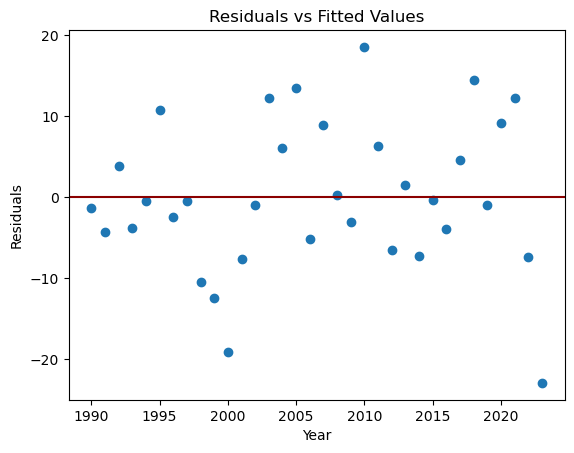

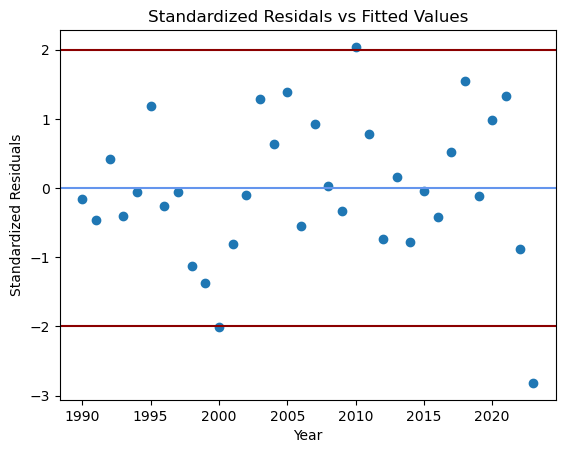

In [7]:
# --------------------------------------------------
# Demand Estimation for Coffee using OLS Regression
# --------------------------------------------------

# Step 1: Import libraries
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Step 2: Load the dataset
df = pd.read_csv("Chapter_06-coffee_demand.csv")

# Step 3: Display the first few rows
print(df.head())

# Step 4: Estimate the demand function using OLS
model = smf.ols(
    formula="Coffee_consumption ~ Coffee_price + Tea_price + Sugar_price + Annual_income",
    data=df).fit()

# Step 5: Print regression results
print(model.summary())

# --------------------------------------------------
# Step 6: Extract residuals
# --------------------------------------------------

# Regular residuals
df["residuals"] = model.resid

# Standardized residuals
influence = model.get_influence()
df["standardized_residuals"] = influence.resid_studentized_internal

# Display first few values
print("\nResiduals:")
print(df[["residuals", "standardized_residuals"]].head())

# --------------------------------------------------
# Step 7: Plot Regular Residuals
# --------------------------------------------------

plt.figure()

# Scatter plot: fitted values vs residuals
plt.scatter(df["Year"], df["residuals"])

# Horizontal reference line at zero
plt.axhline(y=0, color="darkred")

# Labels and title
plt.xlabel("Year")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

# --------------------------------------------------
# Step 8: Plot Standardized Residuals
# --------------------------------------------------

plt.figure()

# Scatter plot: fitted values vs standardized residuals
plt.scatter(df['Year'], df["standardized_residuals"])

# Reference lines
plt.axhline(y=0, color="cornflowerblue")
plt.axhline(y=2, color="darkred")
plt.axhline(y=-2, color="darkred")

# Labels and title
plt.xlabel("Year")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residals vs Fitted Values")

plt.show()
